#**keras sequential model**

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Fold 1 Metrics:
  Accuracy: 0.6866
  Precision: 0.6748
  Recall: 0.6866
  F1-Score: 0.6648


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Fold 2 Metrics:
  Accuracy: 0.7164
  Precision: 0.7244
  Recall: 0.7164
  F1-Score: 0.6972


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3 Metrics:
  Accuracy: 0.6269
  Precision: 0.6556
  Recall: 0.6269
  F1-Score: 0.5997
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Fold 4 Metrics:
  Accuracy: 0.7612
  Precision: 0.7677
  Recall: 0.7612
  F1-Score: 0.7496


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


Fold 5 Metrics:
  Accuracy: 0.6667
  Precision: 0.6395
  Recall: 0.6667
  F1-Score: 0.6401

Average Metrics Across All Folds:
  Accuracy: 0.6915
  Precision: 0.6924
  Recall: 0.6915
  F1-Score: 0.6703
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Test Set Metrics:
  Accuracy: 0.6667
  Precision: 0.7049
  Recall: 0.6667
  F1-Score: 0.6607


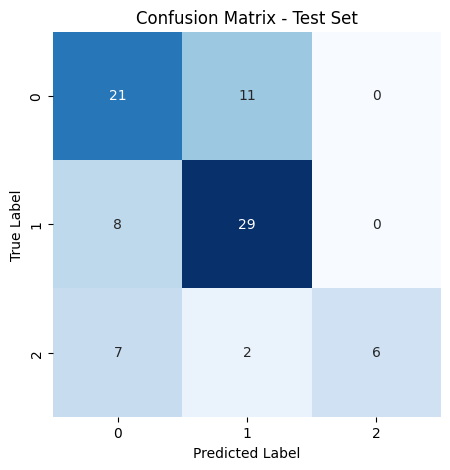

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# preprocess the dataset
epma2 = pd.read_excel('/content/dataset epma preprocessed1.xlsx')
X = epma2.drop(columns=['T'])
y = epma2['T']

# Encode target labels if categorical
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split the dataset into train and test sets (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define MLP model
def create_mlp(input_dim, output_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(output_dim, activation='softmax')  # For classification
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

input_dim = X_train.shape[1]
output_dim = len(np.unique(y_train))

# Cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': [],
}
best_model = None
best_accuracy = 0

# Training and evaluating with cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Train MLP model
    model = create_mlp(input_dim, output_dim)
    model.fit(X_train_fold, y_train_fold, epochs=20, batch_size=32, verbose=0)

    # Evaluate on validation set
    y_val_pred = np.argmax(model.predict(X_val_fold), axis=1)
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    fold_accuracies.append(accuracy)

    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# Average metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

# Save the best model
best_model.save('best_mlp_model.h5')

# Evaluate on test set
y_test_pred = np.argmax(best_model.predict(X_test), axis=1)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

# Test confusion matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
'''
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the MLP model
def create_mlp(input_dim, output_dim, is_classification=True):
    model = Sequential()
    # Input layer + first hidden layer
    model.add(Dense(64, input_dim=input_dim, activation='relu'))
    # Second hidden layer
    model.add(Dense(32, activation='relu'))
    # Optional third hidden layer
    model.add(Dense(16, activation='relu'))
    # Output layer
    if is_classification:
        model.add(Dense(output_dim, activation='softmax'))
        loss = 'categorical_crossentropy'
    else:
        model.add(Dense(1, activation='linear'))
        loss = 'mean_squared_error'
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss=loss, metrics=['accuracy'] if is_classification else ['mse'])
    return model

# Example usage
input_dim = 14  # Number of features
output_dim = len(df['T'].unique())  # Number of unique classes in T

# For classification
mlp_model = create_mlp(input_dim=input_dim, output_dim=output_dim, is_classification=True)

# Summary of the model
mlp_model.summary()
'''